In [34]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.datasets import fetch_openml

data = fetch_openml(name="house_prices", as_frame=True)
df = data.frame

In [65]:
print("Dataset shape is {}".format(df.shape))

Dataset shape is (1460, 81)


- The dataset contains 81 columns and 1460 rows.

In [36]:
df.head(3)

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500


In [37]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

- df.info() showed us that dataset contains columns of types int, float, object.

In [38]:
null_counts = df.isnull().sum()
print(null_counts[null_counts > 0].sort_values(ascending=False))

PoolQC          1453
MiscFeature     1406
Alley           1369
Fence           1179
FireplaceQu      690
LotFrontage      259
GarageType        81
GarageYrBlt       81
GarageFinish      81
GarageQual        81
GarageCond        81
BsmtExposure      38
BsmtFinType2      38
BsmtFinType1      37
BsmtCond          37
BsmtQual          37
MasVnrArea         8
MasVnrType         8
Electrical         1
dtype: int64


- we can see the columns which contains NoN and number of NoNs

In [39]:
df_objects = df.select_dtypes('object')
df[df_objects.columns] = df[df_objects.columns].fillna('Not exist')

- all object columns's NoN's filling with Not exist

In [40]:
df_num = df.select_dtypes(include = ['int64', 'float64'])

- let's the distributions of each numeric columns

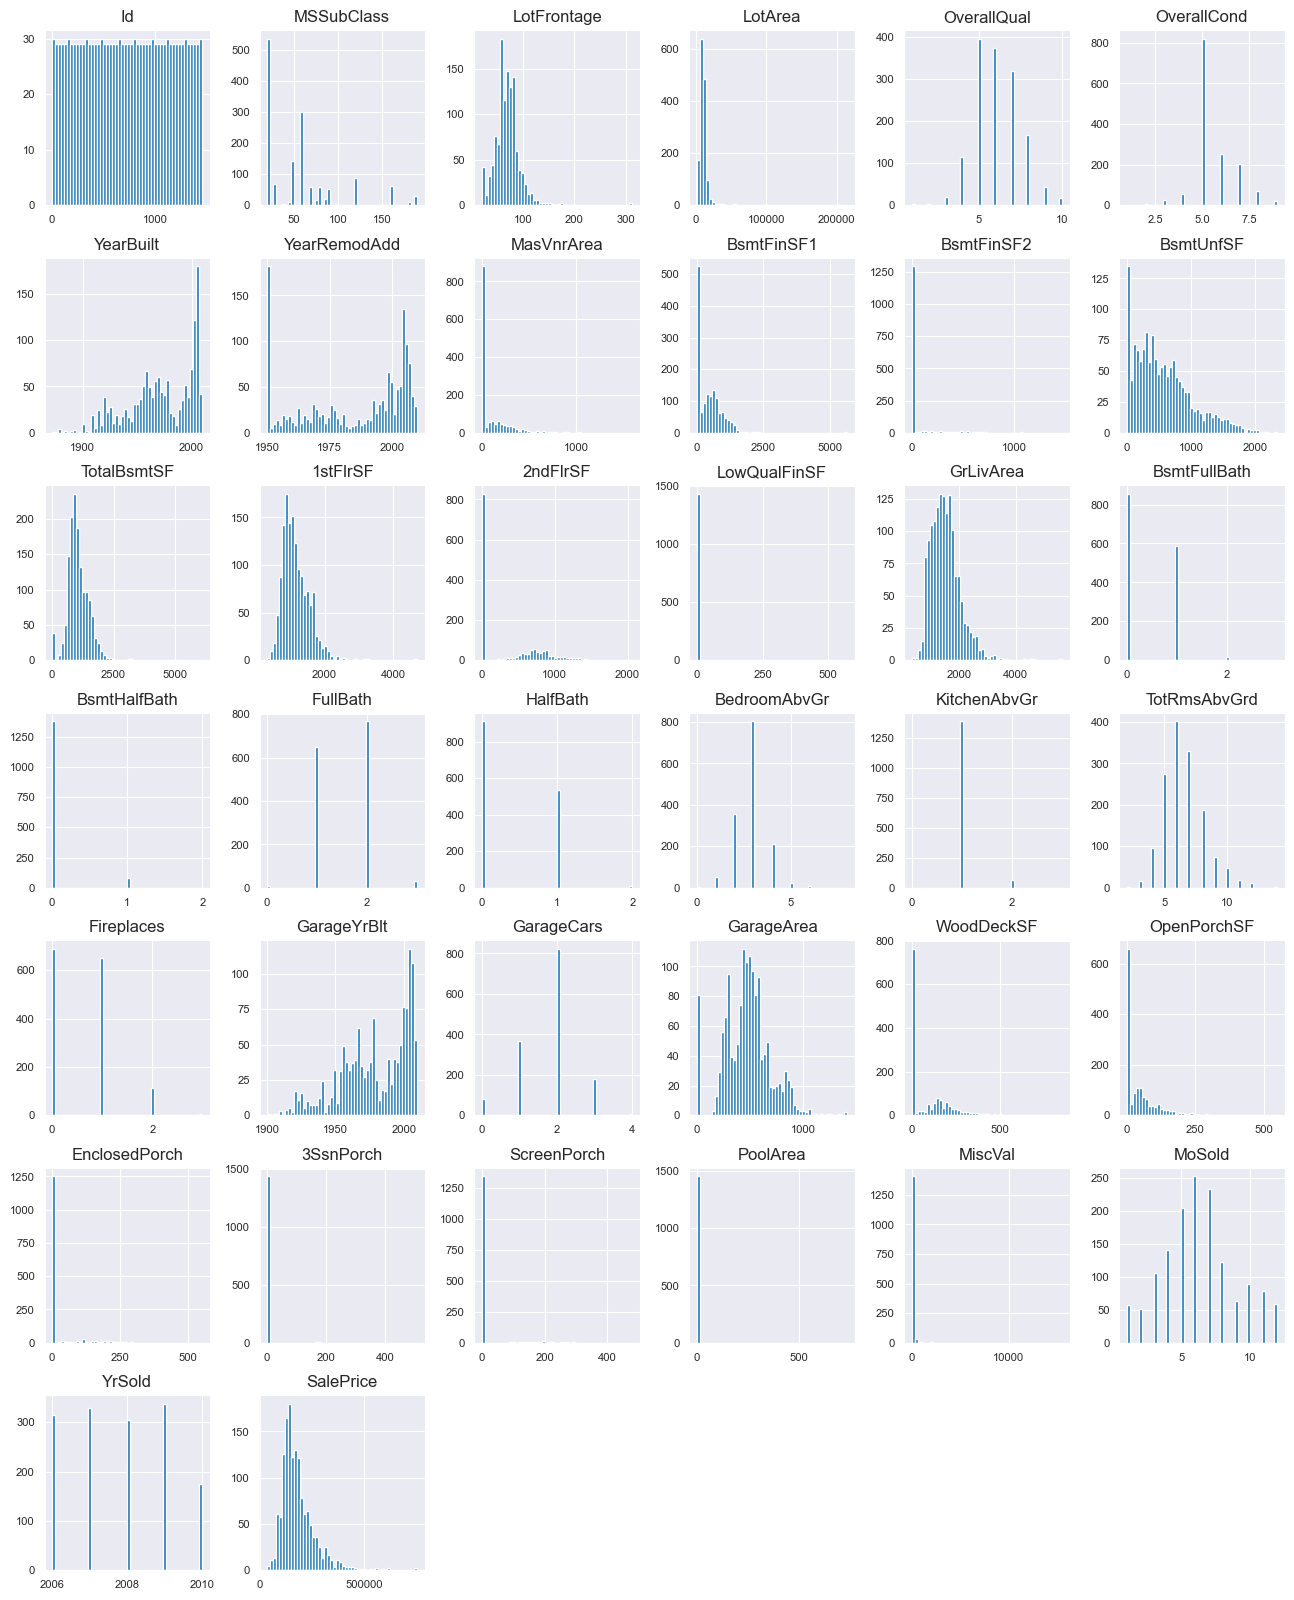

In [41]:
df_num.hist(figsize=(16, 20), bins=50, xlabelsize=8, ylabelsize=8);

In [42]:
null_counts = df_num.isnull().sum()
print(null_counts[null_counts > 0].sort_values(ascending=False))

LotFrontage    259
GarageYrBlt     81
MasVnrArea       8
dtype: int64


- after looking to distributions we can fill numerical columns with median

In [43]:
median = df_num.median()
df[df_num.columns] = df[df_num.columns].fillna(median)

- let's check all the NoN's was filled?

In [44]:
df.isnull().sum().sum()

np.int64(0)

In [45]:
X = df_num.drop(columns=["SalePrice"])
y = df_num["SalePrice"]

Text(0.5, 1.0, 'Distribution of Sale Price')

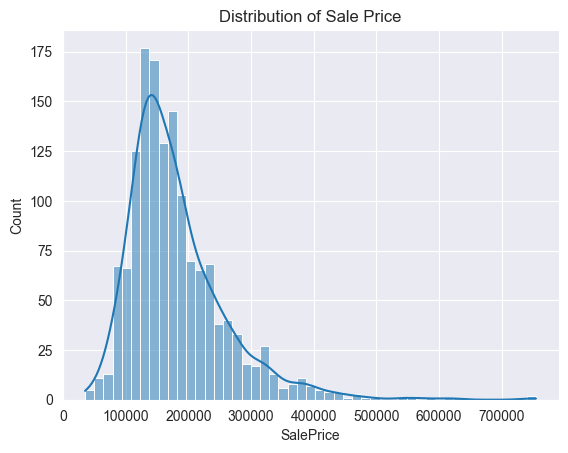

In [46]:
sns.histplot(y, kde=True)
plt.title("Distribution of Sale Price")

- the distribution has long tail in right side we need to fix it by using ln(x+1) transformation

In [47]:
y_log = np.log1p(y)

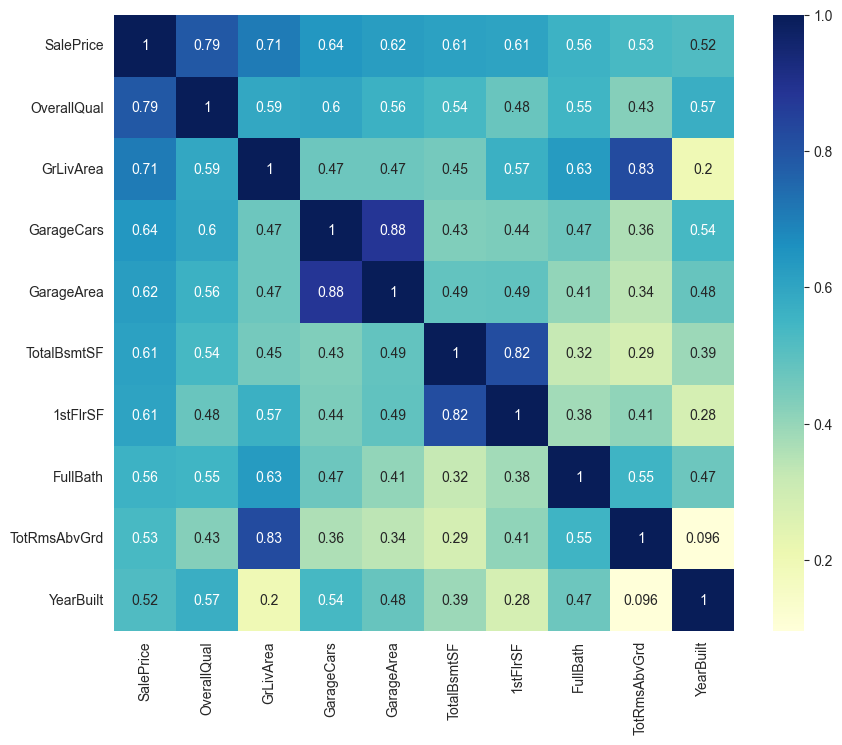

In [48]:
corr = df.corr(numeric_only=True)
top = corr["SalePrice"].sort_values(ascending=False).head(10)
#top_corr_features = top_corr_features.drop('SalePrice')

top_corr_matrix = df[top.index].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(top_corr_matrix, cmap="YlGnBu", annot=True)
plt.show()

In [49]:
X = X.filter(top.index)

In [50]:
top

SalePrice       1.000000
OverallQual     0.790982
GrLivArea       0.708624
GarageCars      0.640409
GarageArea      0.623431
TotalBsmtSF     0.613581
1stFlrSF        0.605852
FullBath        0.560664
TotRmsAbvGrd    0.533723
YearBuilt       0.522897
Name: SalePrice, dtype: float64

In [51]:
X

,OverallQual,GrLivArea,GarageCars,GarageArea,TotalBsmtSF,1stFlrSF,FullBath,TotRmsAbvGrd,YearBuilt
0,7,1710,2,548,856,856,2,8,2003
1,6,1262,2,460,1262,1262,2,6,1976
2,7,1786,2,608,920,920,2,6,2001
3,7,1717,3,642,756,961,1,7,1915
4,8,2198,3,836,1145,1145,2,9,2000
...,...,...,...,...,...,...,...,...,...
1455,6,1647,2,460,953,953,2,7,1999
1456,6,2073,2,500,1542,2073,2,7,1978
1457,7,2340,1,252,1152,1188,2,9,1941
1458,5,1078,1,240,1078,1078,1,5,1950


In [52]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, LassoCV
from sklearn.metrics import mean_squared_error, r2_score

X_train, X_test, y_train, y_test = train_test_split(X, y_log,test_size=0.33, random_state=42)


-with ten features

In [53]:
model_10 = LinearRegression()
model_10.fit(X_train, y_train)

y_pred_test = model_10.predict(X_test)
y_pred_train = model_10.predict(X_train)
print("train R²:", r2_score(y_train, y_pred_train))
print("test R²:", r2_score(y_test, y_pred_test))
print("train MSE:", mean_squared_error(y_train, y_pred_train))
print("test MSE:", mean_squared_error(y_test, y_pred_test))

train R²: 0.7977929711133788
test R²: 0.8351014589205463
train MSE: 0.031136369930881824
test MSE: 0.028103521690524897


In [54]:
X_2 = X[['OverallQual', 'GrLivArea']]
X_train_2 , X_test_2 , y_train_2, y_test_2 = train_test_split(X_2, y_log,test_size=0.33, random_state=42)

- with two features

In [55]:
model_2 = LinearRegression()
model_2.fit(X_train_2, y_train_2)

y_pred_test_2 = model_2.predict(X_test_2)
y_pred_train_2 = model_2.predict(X_train_2)
print("train R²:", r2_score(y_train_2, y_pred_train_2))
print("test R²:", r2_score(y_test_2, y_pred_test_2))
print("train MSE:", mean_squared_error(y_train_2, y_pred_train_2))
print("test MSE:", mean_squared_error(y_test_2, y_pred_test_2))

train R²: 0.7195657885621761
test R²: 0.7755340459616581
train MSE: 0.04318199716736423
test MSE: 0.03825554651245435


- feature importances

In [56]:
coef_df = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model_10.coef_
}).sort_values(by="Coefficient", key=abs, ascending=False)

print(coef_df)

        Feature  Coefficient
0   OverallQual     0.108085
2    GarageCars     0.097170
6      FullBath    -0.015070
7  TotRmsAbvGrd     0.007007
8     YearBuilt     0.002439
1     GrLivArea     0.000197
5      1stFlrSF     0.000077
4   TotalBsmtSF     0.000039
3    GarageArea     0.000025


### we can see that feature FullBath has a negative coefficent it says that here is Negative linear relationship

In [57]:
import statsmodels.api as sm

X_with_constant = sm.add_constant(X)

# 2. Обучение модели (Ordinary Least Squares)
model = sm.OLS(y_log, X_with_constant).fit()

print(model.summary())


                            OLS Regression Results                            
Dep. Variable:              SalePrice   R-squared:                       0.813
Model:                            OLS   Adj. R-squared:                  0.812
Method:                 Least Squares   F-statistic:                     700.8
Date:                Mon, 23 Mar 2026   Prob (F-statistic):               0.00
Time:                        15:51:13   Log-Likelihood:                 492.90
No. Observations:                1460   AIC:                            -965.8
Df Residuals:                    1450   BIC:                            -912.9
Df Model:                           9                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
const            5.8540      0.415     14.113   

- the statmodels shows us that, the model predicts 81% of variance. Also, the GarageArea, FullBath, TotRmsAbvGrd this features p-value is less than 0.05 we can delete it in order to improve model.

Text(0.5, 1.0, 'Residuals vs Predicted')

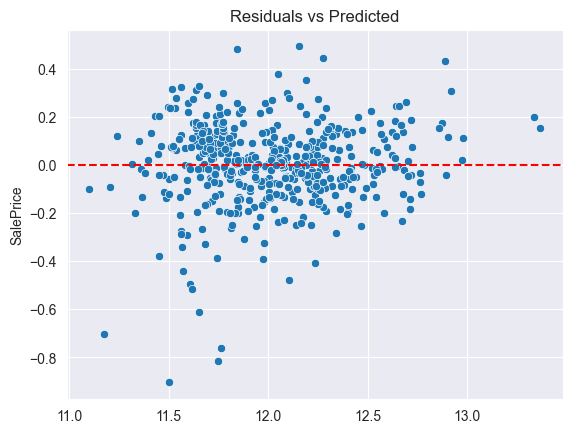

In [58]:
residuals = y_test - y_pred_test
sns.scatterplot(x=y_pred_test, y=residuals)
plt.axhline(0, color='red', linestyle='--')
plt.title("Residuals vs Predicted")

### The residual plot shows a random distribution of errors around the horizontal axis. This constant variance (homoscedasticity) and the absence of clear patterns confirm that the linear regression model has captured the underlying data trends effectively without systematic bias.

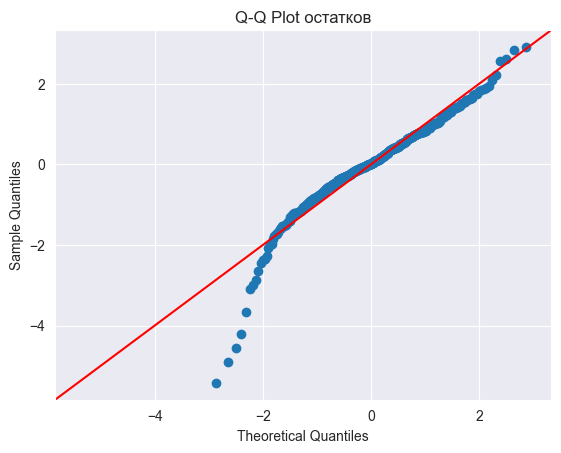

In [59]:
fig = sm.qqplot(residuals, line='45', fit=True)
plt.title('Q-Q Plot остатков')
plt.show()

### The Q-Q plot shows most points follow the 45 - degree reference line closely, indicating that are residuals normally distibuted. But, here is extreme ends, the model struggles slightly with outliers or very high-end property prices.

-----

# Lasso regression

In [62]:
model_Lasso = LassoCV()
model_Lasso.fit(X_train, y_train)

y_pred_test_Lasso = model_Lasso.predict(X_test)
y_pred_train_Lasso = model_Lasso.predict(X_train)
print("train R²:", r2_score(y_train, y_pred_train_Lasso))
print("test R²:", r2_score(y_test, y_pred_test_Lasso))
print("train MSE:", mean_squared_error(y_train, y_pred_train_Lasso))
print("test MSE:", mean_squared_error(y_test, y_pred_test_Lasso))

train R²: 0.7255415749294178
test R²: 0.798126362463934
train MSE: 0.042261829871583986
test MSE: 0.034405156735173144


### I used LassoCV to perform automated feature selection, effectively reducing the dimensionality of the dataset by shrinking coefficients of non-significant features to zero. This can be used to interpretability and prevent overfitting

---

## Let's evalute the results of each model

In [64]:
print('Linear regression with 10 features:')
print("train R²:", r2_score(y_train, y_pred_train))
print("test R²:", r2_score(y_test, y_pred_test))
print("train MSE:", mean_squared_error(y_train, y_pred_train))
print("test MSE:", mean_squared_error(y_test, y_pred_test))
print()

print('Linear regression with 2 features:')
print("train R²:", r2_score(y_train_2, y_pred_train_2))
print("test R²:", r2_score(y_test_2, y_pred_test_2))
print("train MSE:", mean_squared_error(y_train_2, y_pred_train_2))
print("test MSE:", mean_squared_error(y_test_2, y_pred_test_2))
print()

print('LassoCV')
print("train R²:", r2_score(y_train, y_pred_train_Lasso))
print("test R²:", r2_score(y_test, y_pred_test_Lasso))
print("train MSE:", mean_squared_error(y_train, y_pred_train_Lasso))
print("test MSE:", mean_squared_error(y_test, y_pred_test_Lasso))

Linear regression with 10 features:
train R²: 0.7977929711133788
test R²: 0.8351014589205463
train MSE: 0.031136369930881824
test MSE: 0.028103521690524897

Linear regression with 2 features:
train R²: 0.7195657885621761
test R²: 0.7755340459616581
train MSE: 0.04318199716736423
test MSE: 0.03825554651245435

LassoCV
train R²: 0.7255415749294178
test R²: 0.798126362463934
train MSE: 0.042261829871583986
test MSE: 0.034405156735173144


n## Model Performance Comparison:

Best Model: The Linear Regression model with 10 features achieved the highest accuracy (R
2
 =0.835), suggesting that the selected features have strong predictive power.

Regularization Impact: Applying LassoCV resulted in a slightly lower R
2
  compared to the 10-feature linear model. This indicates that with the current feature set, the penalty was too restrictive, and all selected variables are likely significant.

Generalization: Across all models, the test performance closely followed the training results, demonstrating that the models are not overfitting and generalize well to unseen data

---

----

# Conclusion

## In this notebook, I developed a predictive model for a real state housing the Ames Housing dataset.

 - The linear regression model with 10 features showed the best R^2 score = 0.835 score on the test set. It means that the features explain approximately 83.5% of the variance in house prices.
  - The model demonstrated strong generalization capabilities, as the test performance was consistent with the training performance, suggesting no signs of overfitting.
  - Applying LassoCV provided a robust baseline but resulted in a slightly lower R^2 (0.798) compared to the unregularized 10-feature model. This suggests that with the current limited feature set, the complexity penalty was not necessary to prevent overfitting.
  - (Residual and Q-Q plots) confirmed that the model's errors are approximately normal and homoscedastic.


## Future Improvements:
To further improve accuracy, potential next steps include:

1. Feature Engineering: Creating composite features (e.g., Total Square Footage).

2. Advanced Algorithms: Implementing non-linear models like Random Forest or Gradient Boosting to capture complex interactions.

3. Outlier Handling: Implementing a more robust strategy for high-end luxury properties identified during residual analysis.